In [1]:
# significance test of difference between historical wetlands and adjacent upland zones

### **Peak-Greenness Vegetation Index Analysis**

To evaluate differences in crop performance between historical wetlands and adjacent upland zones, we compared early- to mid-season Enhanced Vegetation Index (EVI₂) values for corn and soybean fields across the Des Moines Lobe. Because peak greenness can occur at slightly different times depending on crop, weather, and microtopographic conditions, we identified the maximum growing-season EVI₂ for each wetland–year–crop combination using a two-step procedure.

First, we extracted median EVI₂ values for each historical wetland footprint and its adjacent upland zone for **July** and **August**, the two months that consistently encompass the peak greenness period for both crops in this region. These monthly values were obtained from Landsat Collection 2 surface reflectance mosaics and combined with wetland/upland masks derived from historical wetland footprints.

For each wetland–year–crop, we then selected the **peak greenness month** as the month (July or August) with the **higher upland EVI₂ value**. This approach ensures that peak-season comparisons reflect the period when overall vegetation vigor is maximal and minimizes bias introduced by interannual shifts in crop phenology. The corresponding wetland EVI₂ value was taken from the same month.

This procedure produced paired distributions of **peak wetland EVI₂** and **peak upland EVI₂** across all wetlands in each year (typically 50,000–80,000 wetlands per year). To assess whether upland and wetland zones differed in their peak-season vegetation activity, we compared these two distributions using the **Mann–Whitney U test** (two-sided). This nonparametric test evaluates whether two independent samples originate from the same underlying distribution and is robust to non-normality, unequal variances, and large sample sizes.

For each year and crop, we report:

- the number of wetlands included in the analysis  
- the median peak-season EVI₂ for wetlands and uplands  
- the median difference (ΔEVI₂ = upland – wetland)  
- the Mann–Whitney U statistic and associated p-value  

Together, these analyses provide a robust, distribution-level test of whether historical wetland footprints systematically exhibit reduced vegetation vigor relative to their adjacent upland fields during the peak of the growing season.


In [14]:
#!/usr/bin/env python3
"""
compare_evi2_distributions.py

Loads a single pooled CSV and compares the distributions of
wet_evi2_mean and upl_evi2_mean.
"""

from pathlib import Path
import pandas as pd
from scipy.stats import ks_2samp, mannwhitneyu
import os

# -----------------------
# File to test
# -----------------------
FILE = Path(os.environ.get("DML_NDVI_DATA_ROOT", "./ndvi_wetlands_data")) / "NDVI_wetlands/upland_rasteronly_corn_2003_07_detailed.csv"

# -----------------------
# Load data
# -----------------------
if not FILE.exists():
    raise FileNotFoundError(f"File not found: {FILE}")

df = pd.read_csv(FILE)

# -----------------------
# Check required columns
# -----------------------
required = ["wet_evi2_mean", "upl_evi2_mean"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Extract
wet = pd.to_numeric(df["wet_evi2_mean"], errors="coerce")
upl = pd.to_numeric(df["upl_evi2_mean"], errors="coerce")

# Drop NaNs
wet = wet.dropna()
upl = upl.dropna()

print("\n=== BASIC INFO ===")
print(f"Rows in file: {len(df)}")
print(f"Rows with valid wet_evi2_mean: {len(wet)}")
print(f"Rows with valid upl_evi2_mean: {len(upl)}")

print("\n=== UNIQUE VALUES ===")
print("wet, unique values:", wet.nunique())
print("upl, unique values:", upl.nunique())

print("\n=== SAMPLE VALUES ===")
print("wet (first 10):", wet.head(10).tolist())
print("upl (first 10):", upl.head(10).tolist())

print("\n=== MIN / MAX ===")
print("wet: min =", wet.min(), " max =", wet.max())
print("upl: min =", upl.min(), " max =", upl.max())

print("\n=== DESCRIPTIVE STATS ===")
print("wet describe():\n", wet.describe())
print("\nupl describe():\n", upl.describe())

print("\n=== IDENTICAL CHECK ===")
identical = wet.equals(upl)
print("Are the two columns *exactly identical*?", identical)

# -----------------------
# Statistical tests
# -----------------------

print("\n=== KS TEST ===")
try:
    ks_stat, ks_p = ks_2samp(upl.values, wet.values)
    print("KS statistic:", ks_stat)
    print("KS p-value:", ks_p)
except Exception as e:
    print("KS test failed:", e)

print("\n=== MANN–WHITNEY TEST ===")
try:
    mw_stat, mw_p = mannwhitneyu(upl.values, wet.values, alternative="two-sided")
    print("MW statistic:", mw_stat)
    print("MW p-value:", mw_p)
except Exception as e:
    print("MW test failed:", e)

print("\n--- DONE ---\n")



=== BASIC INFO ===
Rows in file: 236404
Rows with valid wet_evi2_mean: 236392
Rows with valid upl_evi2_mean: 144675

=== UNIQUE VALUES ===
wet, unique values: 58767
upl, unique values: 142136

=== SAMPLE VALUES ===
wet (first 10): [0.7330242395401001, 0.7330242395401001, 0.7330242395401001, 0.7330242395401001, 0.6720369458198547, 0.6720369458198547, 0.6720369458198547, 0.6720369458198547, 0.6391330361366272, 0.6391330361366272]
upl (first 10): [0.7067908048629761, 0.7172874212265015, 0.6137595772743225, 0.5725473761558533, 0.6295666098594666, 0.6510797739028931, 0.6516913175582886, 0.7256807088851929, 0.7202961444854736, 0.6275976300239563]

=== MIN / MAX ===
wet: min = 0.1194281131029129  max = 0.9755590558052064
upl: min = 0.1343038529157638  max = 0.932344138622284

=== DESCRIPTIVE STATS ===
wet describe():
 count    236392.000000
mean          0.661344
std           0.110814
min           0.119428
25%           0.606417
50%           0.688786
75%           0.738793
max           0

In [15]:
#!/usr/bin/env python3
"""
compare_july_august_evi2_wetland_upland.py

For each year, crop, and month (July, August), compare the distributions of
wet_evi2_mean and upl_evi2_mean from the pooled NDVI/EVI2 data.

Inputs (per crop/year/month):
    $DML_NDVI_DATA_ROOT/NDVI_wetlands/
        upland_rasteronly_{crop}_{year}_{month}_pooled.csv

Where:
    crop  ∈ {"corn", "soy"}
    year  ∈ [2003, 2023]
    month ∈ {"07", "08"}   # July, August

For each file, the script:
    - Loads the CSV.
    - Extracts wet_evi2_mean and upl_evi2_mean.
    - Drops NaNs separately for wetlands and uplands.
    - Computes:
        * n_wet, n_upl
        * medians for each
    - Compares the two distributions using:
        * Kolmogorov–Smirnov test (ks_2samp)
        * Mann–Whitney U test (mannwhitneyu)

Output:
    - july_august_evi2_wetland_upland_comparison.csv
      written to your Google Drive NASA UMRB NDVI_wetlands/analysis folder.
"""

from pathlib import Path
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp, mannwhitneyu
import os

# ==========================
# USER SETTINGS
# ==========================

YEARS = list(range(2003, 2024))
CROPS = ["corn", "soy"]
MONTHS = ["07", "08"]  # July, August

# ------------- INPUT -------------
IN_ROOT = Path(os.environ.get("DML_NDVI_DATA_ROOT", "./ndvi_wetlands_data"))
POOLED_DIR = IN_ROOT / "NDVI_wetlands"

POOLED_TEMPLATE = "upland_rasteronly_{crop}_{year}_{month}_pooled.csv"

# ------------- OUTPUT -------------
OUT_ROOT = Path(os.environ.get("DML_PROJECT_ROOT", "."))
OUT_DIR = OUT_ROOT / "NDVI_wetlands" / "analysis"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_SUMMARY = OUT_DIR / "july_august_evi2_wetland_upland_comparison.csv"

# Column names
COL_WET_EVI2 = "wet_evi2_mean"
COL_UPL_EVI2 = "upl_evi2_mean"


def pooled_path(year: int, month: str, crop: str) -> Path:
    """Build path to the pooled CSV for the given year, month, crop."""
    fname = POOLED_TEMPLATE.format(year=year, month=month, crop=crop)
    return POOLED_DIR / fname


def analyze_file(year: int, month: str, crop: str) -> dict | None:
    """
    Load one pooled file and compare wet vs upland EVI2 distributions.

    Returns a dict of summary stats, or None if file missing or invalid.
    """
    path = pooled_path(year, month, crop)
    if not path.exists():
        print(f"[WARN] Missing file: {path}")
        return None

    df = pd.read_csv(path)

    if COL_WET_EVI2 not in df.columns or COL_UPL_EVI2 not in df.columns:
        print(f"[WARN] Required columns missing in {path.name}; skipping.")
        return None

    # Coerce to numeric and drop NaNs separately
    wet = pd.to_numeric(df[COL_WET_EVI2], errors="coerce").dropna()
    upl = pd.to_numeric(df[COL_UPL_EVI2], errors="coerce").dropna()

    n_wet = len(wet)
    n_upl = len(upl)

    if n_wet == 0 or n_upl == 0:
        print(f"[INFO] No valid data for {crop}, {year}-{month}; skipping.")
        return None

    med_wet = wet.median()
    med_upl = upl.median()

    # KS test
    try:
        ks_stat, ks_p = ks_2samp(upl.values, wet.values)
    except Exception as e:
        print(f"[WARN] KS test failed for {crop}, {year}-{month}: {e}")
        ks_stat, ks_p = np.nan, np.nan

    # Mann–Whitney U test
    try:
        mw_stat, mw_p = mannwhitneyu(upl.values, wet.values, alternative="two-sided")
    except Exception as e:
        print(f"[WARN] Mann–Whitney test failed for {crop}, {year}-{month}: {e}")
        mw_stat, mw_p = np.nan, np.nan

    return {
        "year": year,
        "crop": crop,
        "month": month,
        "n_wet": n_wet,
        "n_upl": n_upl,
        "median_wet_evi2": med_wet,
        "median_upl_evi2": med_upl,
        "delta_median_evi2": med_upl - med_wet,
        "ks_stat": ks_stat,
        "ks_p_value": ks_p,
        "mw_stat": mw_stat,
        "mw_p_value": mw_p,
    }


def main():
    rows = []

    for crop in CROPS:
        print(f"\n=== Processing crop: {crop} ===")
        for year in YEARS:
            for month in MONTHS:
                result = analyze_file(year, month, crop)
                if result is not None:
                    rows.append(result)

    if not rows:
        print("[WARN] No summary rows produced.")
        return

    df_summary = pd.DataFrame(rows).sort_values(["crop", "year", "month"])
    df_summary.to_csv(OUT_SUMMARY, index=False)

    print(f"\n[OK] Saved July/August comparison summary → {OUT_SUMMARY}")
    print("\nSummary (first rows):")
    print(df_summary.head())


if __name__ == "__main__":
    main()



=== Processing crop: corn ===

=== Processing crop: soy ===

[OK] Saved July/August comparison summary → /Users/kimberlyvanmeter/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/NDVI_wetlands/analysis/july_august_evi2_wetland_upland_comparison.csv

Summary (first rows):
   year  crop month  n_wet  n_upl  median_wet_evi2  median_upl_evi2  \
0  2003  corn    07  59098  54067         0.688786         0.699360   
1  2003  corn    08  59099  54063         0.645881         0.650387   
2  2004  corn    07  59014  54938         0.661861         0.695405   
3  2004  corn    08  59282  55039         0.650818         0.666304   
4  2005  corn    07  54993  50527         0.703680         0.714347   

   delta_median_evi2   ks_stat     ks_p_value       mw_stat     mw_p_value  
0           0.010574  0.075815  1.365342e-141  1.714182e+09  4.705538e-100  
1           0.004506  0.047566   5.944436e-56  1.647937e+09   4.224806e-20  
2        

Unique crops: ['corn' 'soy']
Unique month labels: ['July' 'August']


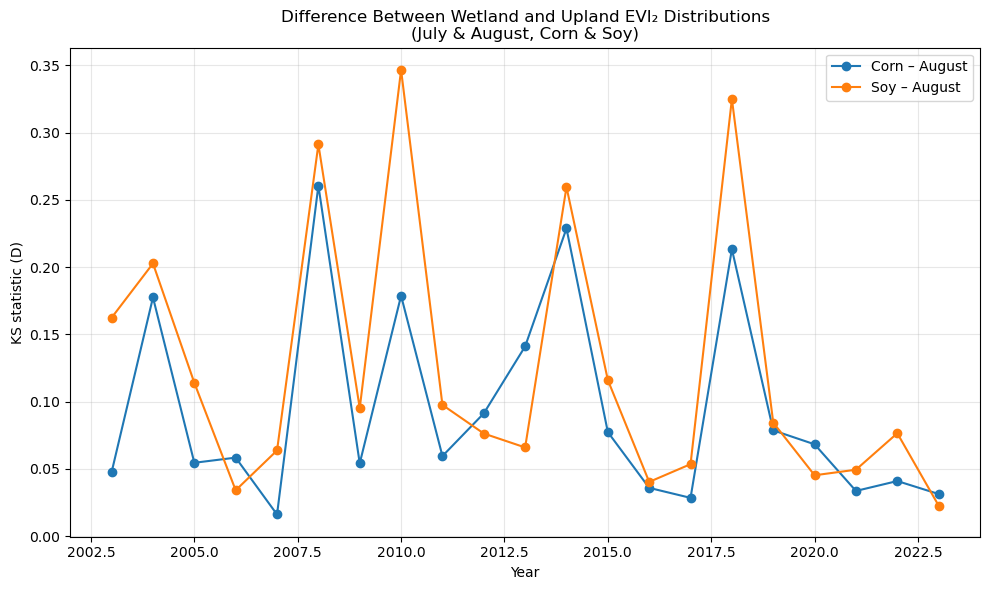

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os

# Path to summary file
path = Path(os.environ.get("DML_PROJECT_ROOT", ".")) / "NDVI_wetlands/analysis/july_august_evi2_wetland_upland_comparison.csv"

df = pd.read_csv(path)

# Month is stored as integers 7, 8 → map directly
df["month_label"] = df["month"].map({7: "July", 8: "August"})

print("Unique crops:", df["crop"].unique())
print("Unique month labels:", df["month_label"].unique())

plt.figure(figsize=(10, 6))

for crop in ["corn", "soy"]:
    for m in ["August"]: # , "August"
        sub = df[(df["crop"] == crop) & (df["month_label"] == m)]
        if sub.empty:
            print(f"[INFO] No data for {crop}, {m}")
            continue
        plt.plot(
            sub["year"],
            sub["ks_stat"],
            marker="o",
            label=f"{crop.title()} – {m}"
        )

plt.xlabel("Year")
plt.ylabel("KS statistic (D)")
plt.title("Difference Between Wetland and Upland EVI₂ Distributions\n(July & August, Corn & Soy)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
